# Vocabulary

In [1]:
import polars as pl
import polars_corpus as plc
import polars.selectors as cs
import matplotlib.pyplot as plt
import seaborn as sns

pl.Config.set_float_precision(3)
pl.Config.set_tbl_rows(15)

polars.config.Config

In [27]:
brown = (
    pl.scan_parquet("../../data/brown.parquet")
    .filter(plc.is_letters("token"))
    .with_columns(pl.col("token").str.to_lowercase())
    .collect()
)

In [63]:
msttr = brown.group_by("file_id").agg(
    pl.col("category").first(),
    plc.ttr("token").alias("ttr"),
    plc.ttr(pl.col("token").head(250)).alias("ttr250"),
    plc.msttr("token", 250).alias("msttr"),
    plc.mtld("token").alias("mtld"),
)
msttr.group_by("category").agg(cs.numeric().mean())

category,ttr,ttr250,msttr,mtld
str,f64,f64,f64,f64
"""science_fiction""",0.380,0.599,0.612,102.887
"""news""",0.409,0.611,0.613,99.253
"""reviews""",0.446,0.631,0.645,119.912
"""learned""",0.323,0.568,0.557,73.701
"""government""",0.311,0.542,0.537,66.086
"""belles_lettres""",0.383,0.602,0.605,93.025
"""mystery""",0.354,0.608,0.603,98.598
"""lore""",0.376,0.607,0.607,95.220
"""fiction""",0.377,0.606,0.607,97.180


<Axes: xlabel='mtld', ylabel='category'>

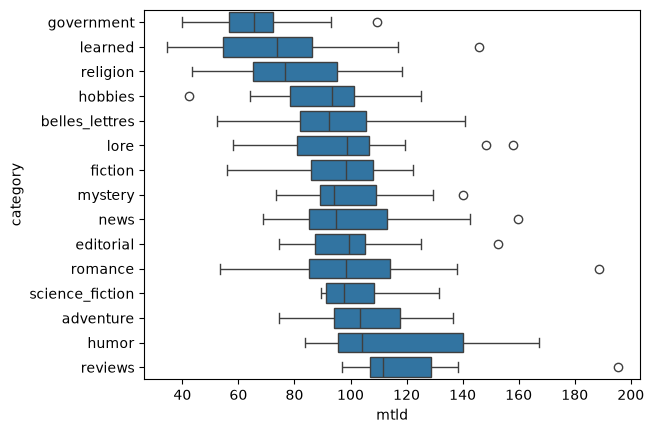

In [46]:
z = msttr.with_columns(m=pl.col("mtld").mean().over("category")).sort(by="m")


sns.boxplot(z, x="mtld", y="category")

<Axes: xlabel='msttr', ylabel='ttr250'>

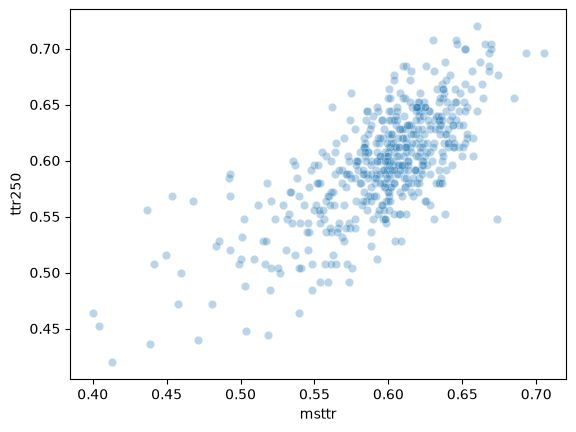

In [56]:
sns.scatterplot(z, x="msttr", y="ttr250", alpha=0.3)

<Axes: xlabel='msttr', ylabel='mtld'>

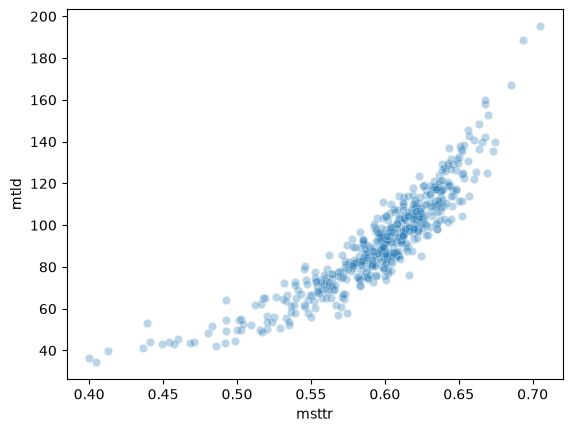

In [47]:
sns.scatterplot(z, x="msttr", y="mtld", alpha=0.3)

<Axes: xlabel='nouns_mtld', ylabel='category'>

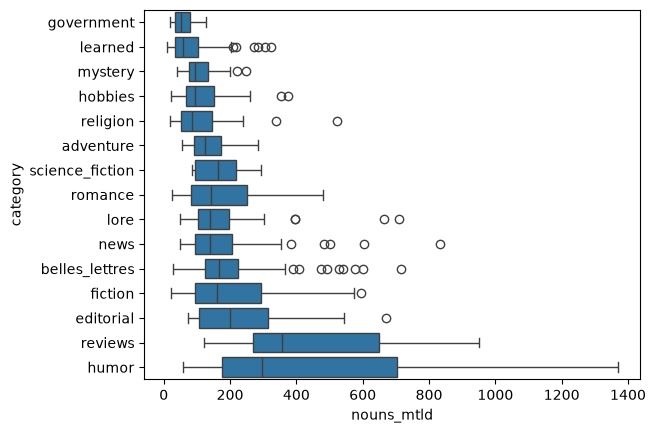

In [66]:
nouns = (
    brown.filter(pl.col("tag").str.contains("^N.*"))
    .group_by("file_id")
    .agg(pl.col("category").first(), plc.mtld("token").alias("nouns_mtld"))
    .with_columns(m=pl.col("nouns_mtld").mean().over("category"))
    .sort(by="m")
)

sns.boxplot(nouns, x="nouns_mtld", y="category")

<Axes: xlabel='verbs_mtld', ylabel='category'>

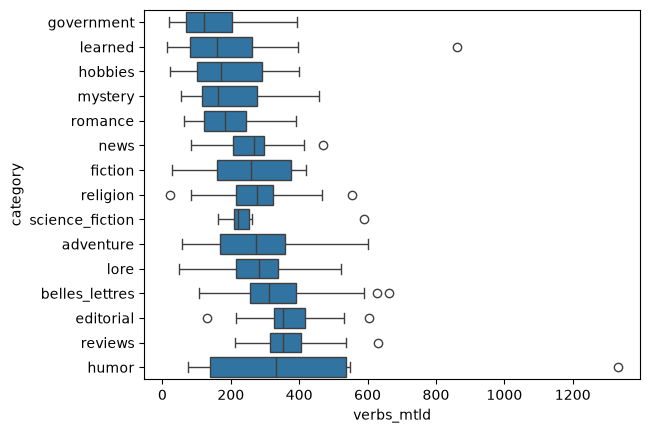

In [67]:
verbs = (
    brown.filter(pl.col("tag").str.contains("^V.*"))
    .group_by("file_id")
    .agg(pl.col("category").first(), plc.mtld("token").alias("verbs_mtld"))
    .with_columns(m=pl.col("verbs_mtld").mean().over("category"))
    .sort(by="m")
)

sns.boxplot(verbs, x="verbs_mtld", y="category")

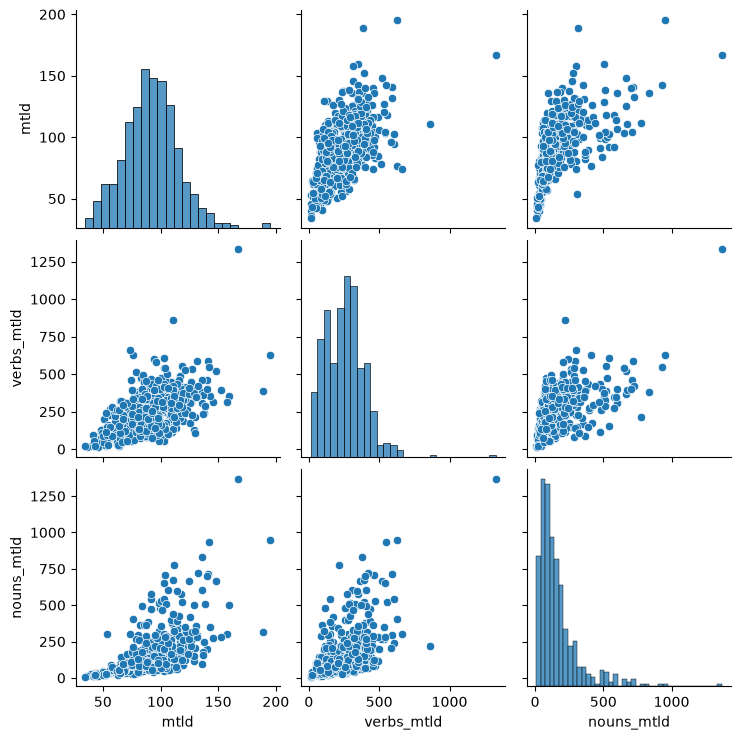

In [96]:
combined = msttr.join(nouns, on=["file_id", "category"]).join(
    verbs, on=["file_id", "category"]
)

sns.pairplot(data=combined.select("mtld", "verbs_mtld", "nouns_mtld").to_pandas())

In [82]:
combined.filter(pl.col("nouns_mtld") > 1000)

file_id,category,ttr,ttr250,msttr,mtld,nouns_mtld,m,verbs_mtld,m_right
str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""cr09""","""humor""",0.509,0.656,0.685,167.263,1368.646,471.314,1331.280,408.544


In [90]:
(brown.filter(pl.col("file_id") == "cr09")["token"].head(250).str.join(" ")).item()

"dear sirs let me begin by clearing up any possible misconception in your minds wherever you are the collective by which i address you in the title above is neither patronizing nor jocose but an exact industrial term in use among professional thieves it is i am reliably given to understand the technical argot for those who engage in your particular branch of the boost burglars who rob while the tenants are absent in contrast to hot-slough prowlers those who work while the occupants are home since the latter obviously require an audacity you do not possess you may perhaps suppose that i am taunting you as socially inferior far from it i merely draw an etymological distinction hoping that specialists and busy people like you will welcome such precision in a layman above all disabuse yourselves of any thought that i propose to vent moral indignation at your rifling my residence to whimper over the loss of a few objets d'art or to shame you into rectitude my object rather is to alert you t

In [92]:
combined.filter(pl.col("verbs_mtld") > 800)

file_id,category,ttr,ttr250,msttr,mtld,nouns_mtld,m,verbs_mtld,m_right
str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""cj68""","""learned""",0.429,0.680,0.631,111.055,217.147,79.743,862.470,183.856
"""cr09""","""humor""",0.509,0.656,0.685,167.263,1368.646,471.314,1331.280,408.544


In [93]:
(brown.filter(pl.col("file_id") == "cj68")["token"].head(250).str.join(" ")).item()

"recent criticism of great expectations has tended to emphasize its symbolic and mythic content to show as zabel has said of dickens generally that much of the novel's impact resides in its allegoric insight and moral metaphor miller's excellent chapter on great expectations has lately illustrated how fruitfully that novel can be read from such a perspective in his analysis however he touches upon but fails to explore an idea generally neglected in discussions of the book which i believe is central to its art the importance of human hands as a recurring feature of the narrative this essay seeks to make that exploration dickens was not for nothing the most theatrical of the great victorian writers he knew instinctively that next to voice and face an actor's hands are his most useful possession that in fiction as in the theatre gesture is an indispensable shorthand for individualizing character and dramatizing action and response it is hardly accidental therefore that many of his most vi

In [31]:
subset = [
    "austen-emma.txt",
    "chesterton-ball.txt",
    "edgeworth-parents.txt",
    "burgess-busterbrown.txt",
    "melville-moby_dick.txt",
    "bryant-stories.txt",
]

books = (
    pl.scan_parquet("../../data/books.parquet")
    .select("token", "file_id")
    .filter(pl.col("file_id").is_in(subset), plc.is_letters("token"))
    .with_columns(pl.col("token").str.to_lowercase())
    .collect()
)

In [32]:
mtld = books.group_by("file_id").agg(plc.mtld("token").alias("mtld")).sort(by="mtld")
mtld

file_id,mtld
str,f64
"""bryant-stories.txt""",55.816
"""burgess-busterbrown.txt""",67.390
"""edgeworth-parents.txt""",77.037
"""chesterton-ball.txt""",79.959
"""austen-emma.txt""",91.232
"""melville-moby_dick.txt""",105.638


<Axes: xlabel='mtld', ylabel='file_id'>

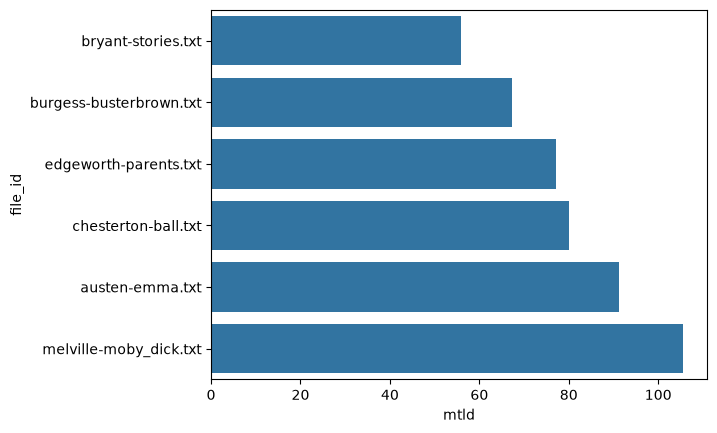

In [33]:
sns.barplot(mtld, y="file_id", x="mtld")

In [34]:
vgc = (
    books.filter(pl.col("file_id") == "austen-emma.txt")
    .with_columns(plc.vocabulary_growth("token").alias("types"))
    .with_row_index()
)

<Axes: xlabel='index', ylabel='types'>

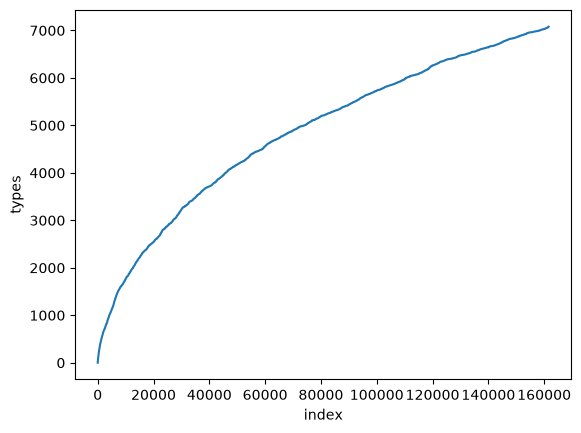

In [35]:
sns.lineplot(vgc, x="index", y="types")

In [36]:
vgc = books.with_columns(
    plc.vocabulary_growth("token").alias("types").over("file_id"),
    pl.row_index().over("file_id").alias("index"),
)

<Axes: xlabel='index', ylabel='types'>

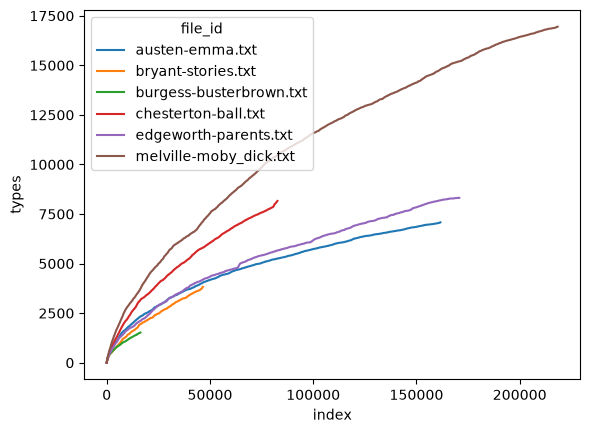

In [37]:
sns.lineplot(vgc, x="index", y="types", hue="file_id")

In [38]:
vgc = books.with_columns(
    plc.vocabulary_growth("token").alias("types").over("file_id"),
    pl.row_index().over("file_id").alias("index"),
)